In [1]:
import os
import sys
import tempfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score   

sys.path.insert(0, os.path.dirname(os.getcwd()))

sns.set_theme(style="whitegrid", palette="muted")

# Load the dataset


c:\Users\Priya Bhaskar\OneDrive\Documents\demand_forecasting\project_1_demand_forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1. correlation
# 2. xgboost feature importance
# 3. shap technique

In [3]:
PARQUET_PATH = os.path.join(tempfile.gettempdir(), "supply_chain_data_processed.parquet")
df = pd.read_parquet(PARQUET_PATH)


In [4]:
df.head()

,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,...,demand_lag_7,demand_lag_14,demand_lag_30,demand_rolling_mean_7,demand_rolling_mean_14,demand_rolling_mean_30,discount_rate,sell_through_rate,supply_gap,price_vs_competitor
0,0,0,0,3,410,200,152,212.24,70.78,0,...,17.87,73.59,135.47,106.825714,137.663571,119.560000,0.000000,0.487805,-48,1.90
1,0,1,1,2,411,363,63,375.34,80.69,0,...,152.76,169.21,144.04,114.037143,144.236429,151.721667,0.000000,0.883212,-300,4.67
2,0,2,0,0,126,94,176,86.82,11.21,5,...,143.44,16.69,74.02,181.832857,127.355714,118.996667,0.446030,0.746032,82,1.12
3,0,3,4,0,113,105,152,98.38,39.90,15,...,77.48,99.26,62.18,160.178571,161.297143,148.466000,0.375940,0.929204,47,2.35
4,0,4,1,3,368,126,132,129.14,28.06,15,...,95.99,74.40,9.26,169.868571,157.407857,150.310333,0.534569,0.342391,6,2.44


In [5]:
TARGET = "Demand Forecast"
features = [c for c in df.columns if c != TARGET]


In [6]:
X = df[features]
y = df[TARGET]

In [7]:
print(X.shape)
print(y.shape)

(70100, 31)
(70100,)


In [8]:
# split the data
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[0:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(56080, 31) (14020, 31)
(56080,) (14020,)


In [9]:
corr_with_target = (df[features + [TARGET]].corr(method="pearson"))[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

In [10]:
corr_with_target

Units Sold                0.996859
supply_gap               -0.899058
sell_through_rate         0.723448
Inventory Level           0.588552
Product ID                0.006772
demand_lag_30            -0.005763
demand_rolling_mean_30    0.005043
Store ID                  0.004908
demand_lag_14            -0.004745
Weather Condition         0.004704
is_weekend               -0.004194
Day                       0.003208
Year                     -0.003180
days_since_start         -0.002909
Discount                  0.002666
Seasonality              -0.002626
price_vs_competitor      -0.001852
Region                   -0.001548
Units Ordered            -0.001325
Holiday/Promotion        -0.001203
demand_rolling_mean_7    -0.001196
Competitor Pricing        0.001104
Category                  0.001102
week_of_year              0.001078
Price                     0.000906
quarter                   0.000887
demand_rolling_mean_14   -0.000831
demand_lag_7              0.000770
Month               

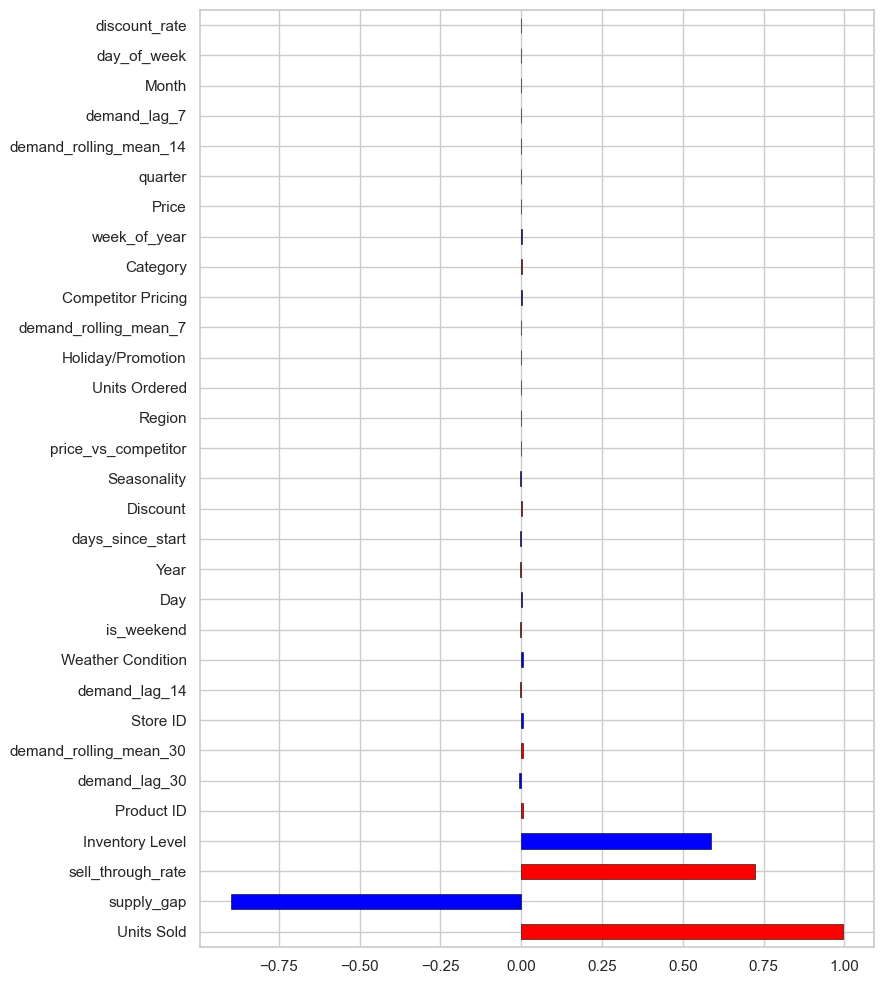

In [11]:
fig, ax = plt.subplots(figsize=(9, 10))
corr_with_target.plot(kind='barh', ax=ax, color=["red", "blue"], edgecolor="black", linewidth=0.4)
plt.tight_layout()
plt.show()

In [12]:
feat_corr = df[features].corr(method="pearson")


In [13]:
feat_corr

,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,...,demand_lag_7,demand_lag_14,demand_lag_30,demand_rolling_mean_7,demand_rolling_mean_14,demand_rolling_mean_30,discount_rate,sell_through_rate,supply_gap,price_vs_competitor
Store ID,1.000000e+00,-2.791715e-17,0.000613,0.002228,0.005071,0.004524,-0.001168,0.001875,0.000982,-0.001182,...,0.005119,0.006106,0.006248,0.012702,0.019766,0.030505,-0.001194,0.002921,-0.004582,-0.010109
Product ID,-2.791715e-17,1.000000e+00,-0.002464,0.007608,0.009126,0.007070,0.005677,0.000772,0.000320,-0.004252,...,0.007101,0.006764,0.007108,0.018581,0.026357,0.037866,-0.000222,0.001604,-0.003919,-0.003240
Category,6.130751e-04,-2.464333e-03,1.000000,0.000268,0.001531,0.001152,-0.001975,0.002708,-0.001580,-0.001808,...,-0.000619,0.000936,0.003483,-0.000920,-0.003443,-0.001033,-0.000478,0.000447,-0.001892,0.002932
Region,2.227958e-03,7.607839e-03,0.000268,1.000000,-0.006248,-0.002284,0.003605,-0.003797,-0.002700,0.000723,...,-0.002917,0.002416,0.004025,-0.001400,0.000229,0.001915,0.001549,0.002316,0.003616,-0.000245
Inventory Level,5.071395e-03,9.126359e-03,0.001531,-0.006248,1.000000,0.590004,0.001308,0.010401,0.005863,0.003070,...,-0.001734,-0.005444,-0.009638,-0.003949,-0.001714,0.001762,-0.005595,-0.005372,-0.531216,-0.002872
Units Sold,4.523913e-03,7.069934e-03,0.001152,-0.002284,0.590004,1.000000,-0.001162,0.001318,0.002994,0.004632,...,0.000914,-0.004849,-0.005791,-0.001260,-0.000929,0.004485,-0.000324,0.726006,-0.901819,-0.001884
Units Ordered,-1.168469e-03,5.676765e-03,-0.001975,0.003605,0.001308,-0.001162,1.000000,0.004841,-0.000696,-0.001410,...,-0.011353,0.000888,-0.003947,-0.005359,-0.002018,-0.001372,-0.007357,-0.001637,0.433161,-0.003449
Price,1.875204e-03,7.720703e-04,0.002708,-0.003797,0.010401,0.001318,0.004841,1.000000,0.001136,-0.007536,...,-0.002459,0.004789,0.000189,0.000348,-0.002797,-0.003412,-0.537915,-0.004175,0.000904,-0.003918
Discount,9.821503e-04,3.202979e-04,-0.001580,-0.002700,0.005863,0.002994,-0.000696,0.001136,1.000000,-0.001870,...,0.002220,0.006668,-0.002152,-0.002421,0.000801,-0.004072,0.619261,-0.000941,-0.002999,-0.004329
Weather Condition,-1.181571e-03,-4.251686e-03,-0.001808,0.000723,0.003070,0.004632,-0.001410,-0.007536,-0.001870,1.000000,...,0.002129,-0.000714,-0.001696,-0.003398,0.000089,0.000706,-0.001502,0.001884,-0.004784,-0.001166


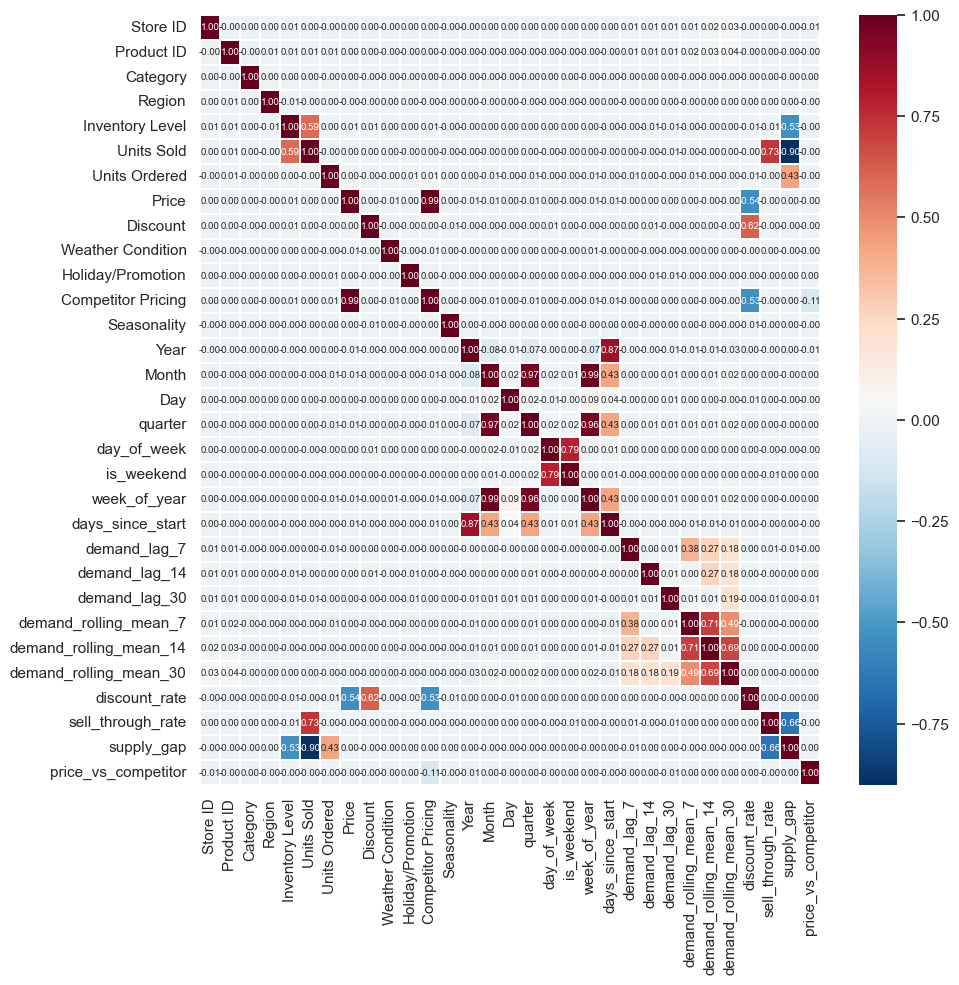

In [14]:
plt.figure(figsize=(10, 10))
sns.heatmap(data=feat_corr, annot=True, fmt=".2f", linewidths=0.3, annot_kws={"size": 7}, cmap="RdBu_r")
plt.show()

In [15]:
# check of the correlation between each feature.
# 1. year vs days_since_start ---> they have 0.87 correlation, which indicate they both provide 87% of importance to the predictor.
# suggesstion: keep only "days_since_start". drop "year" column

# 2. month vs week_of_year ----> they both have 0.99 correlation. indicates multicolinearltiy, which mean they both provide same level of importance to the predictor.
# so consider dropping one column. keep week_of_year and drop month column.

# do the same analysis on other columns and decide what features to be kept and dropped.




In [16]:
model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

In [17]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [18]:
y_pred = model.predict(X_test)

In [19]:
y_pred

array([ 18.608305,  25.74548 ,  90.3683  , ...,  44.21583 , 269.09518 ,
        12.749531], shape=(14020,), dtype=float32)

In [20]:
model.feature_importances_

array([9.08298971e-05, 1.12586975e-04, 2.10369530e-04, 1.06150161e-04,
       1.10122800e-01, 4.97251153e-01, 2.61148363e-02, 3.91270238e-04,
       1.27619685e-04, 1.16542476e-04, 1.39190932e-04, 4.84700664e-04,
       2.05914315e-04, 1.12826849e-04, 1.96729598e-04, 2.47034623e-04,
       1.08234955e-04, 1.39005599e-04, 1.75449328e-04, 1.68346596e-04,
       3.23967106e-04, 2.46912241e-04, 2.86862778e-04, 2.24331510e-04,
       2.53921055e-04, 1.54492634e-04, 2.72549805e-04, 3.42156476e-04,
       9.56944302e-02, 2.65343130e-01, 2.35554326e-04], dtype=float32)

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_log_error, root_mean_squared_error, r2_score

In [22]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [23]:
mae

7.90753010087015

In [24]:
mse

87.23175236339439

In [25]:
rmse

np.float64(9.339794021465055)

In [26]:
r2

0.992568207734499

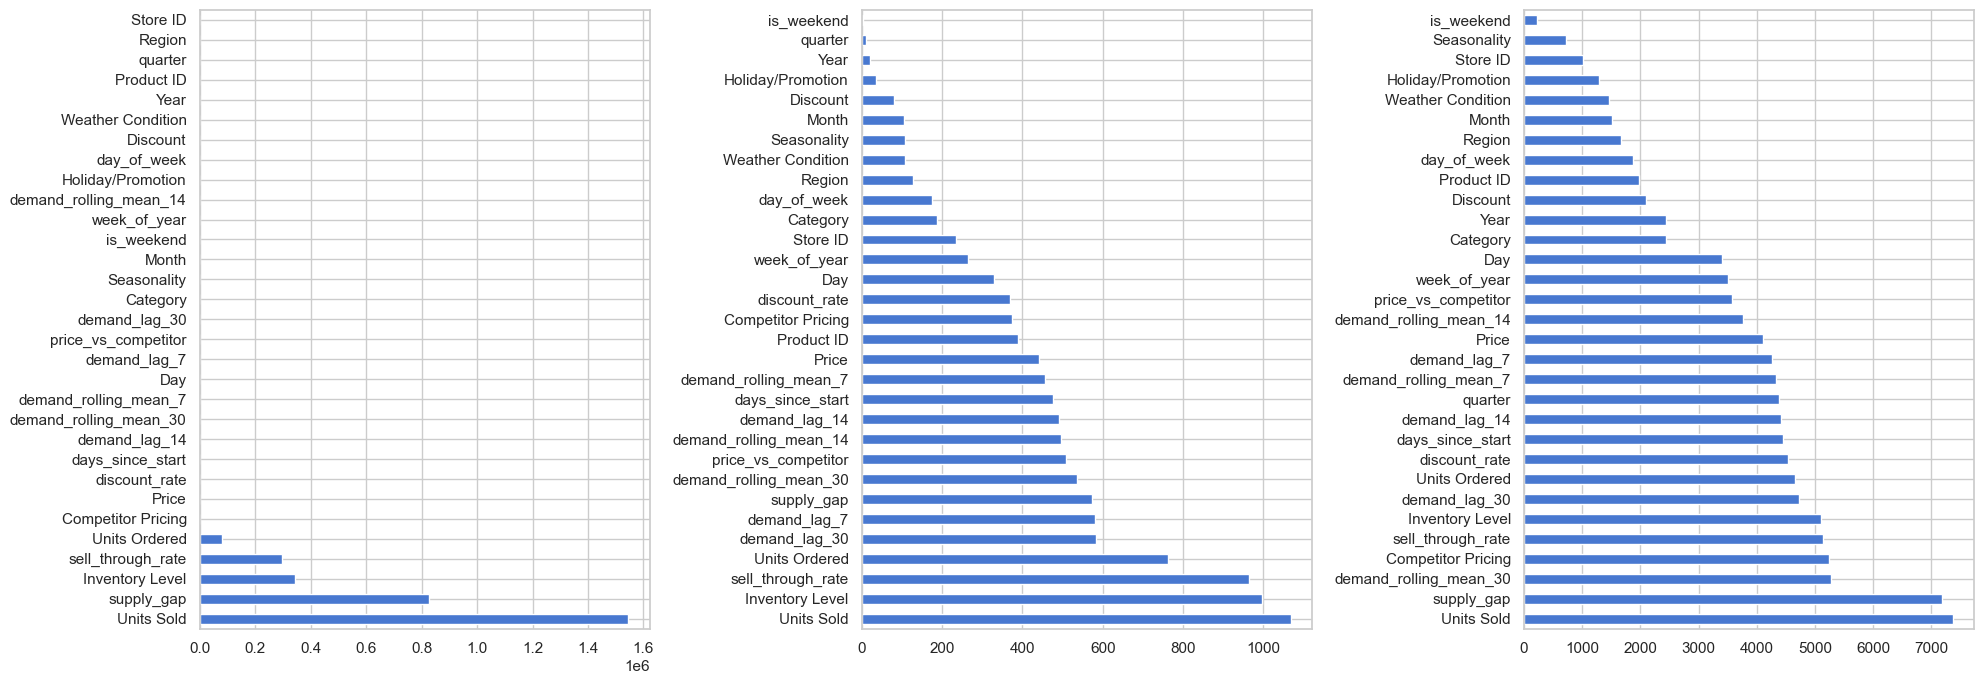

In [27]:
important_types = ["gain", "weight", "cover"]
importance_df = {}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, imp_type in zip(axes, important_types):
    scores = model.get_booster().get_score(importance_type=imp_type)
    imp_df = (
        pd.DataFrame.from_dict(scores, orient="index", columns=[imp_type]).sort_values(imp_type, ascending=False)

    )
    importance_df[imp_type] = imp_df
    imp_df.plot(kind="barh", ax=ax, legend=False, )

plt.tight_layout()
plt.show()


In [28]:
import shap

explainer = shap.TreeExplainer(model=model)
shap_values = explainer.shap_values(X=X_test)
print(shap_values)

[[ 1.5550426e-01  2.1566337e-02  4.3412632e-01 ... -3.0025599e+01
  -1.1523537e+01 -2.6624313e-02]
 [ 1.2894619e-01  9.1827758e-02 -1.1503337e-01 ... -1.9614035e+01
  -1.0048181e+01  1.4041135e-01]
 [ 6.1610073e-02  1.1577650e-01  2.8636819e-01 ...  2.0358959e+01
  -5.5736156e+00 -9.3306433e-03]
 ...
 [ 4.1688994e-02  1.3714930e-01  3.6666515e-01 ... -2.0937523e+01
  -1.7367380e+01  3.8568333e-02]
 [ 2.8094256e-01  2.1513095e-03 -7.8471601e-02 ...  1.2825506e+01
   3.3756973e+01 -6.0732651e-01]
 [ 3.2299662e-01 -4.2366856e-01 -1.2771046e-01 ... -2.2843937e+01
  -2.0327240e+01  2.3883287e-02]]


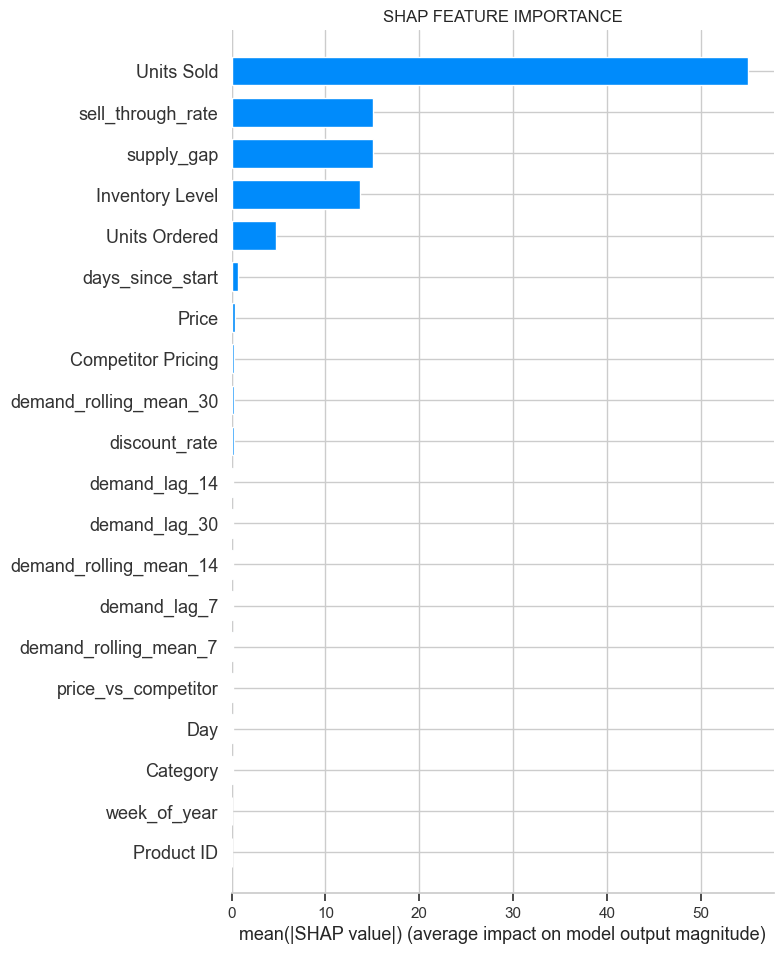

In [29]:
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP FEATURE IMPORTANCE")
plt.show()

In [30]:
df.columns


Index(['Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level',
       'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount',
       'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing',
       'Seasonality', 'Year', 'Month', 'Day', 'quarter', 'day_of_week',
       'is_weekend', 'week_of_year', 'days_since_start', 'demand_lag_7',
       'demand_lag_14', 'demand_lag_30', 'demand_rolling_mean_7',
       'demand_rolling_mean_14', 'demand_rolling_mean_30', 'discount_rate',
       'sell_through_rate', 'supply_gap', 'price_vs_competitor'],
      dtype='str')

In [ ]:
drop_features = ['Store ID', 'Product ID', 'Category', 'Region', 'Demand Forecast', 'demand_lag_14', 'demand_lag_30', 'demand_rolling_mean_7','Discount','demand_rolling_mean_14', 'is_weekend', 'week_of_year','Competitor Pricing', 'price_vs_competitor']

In [32]:
len(drop_features)

13

In [33]:
df = df.drop(labels=drop_features, axis=1)

In [34]:
df.columns

Index(['Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Weather Condition', 'Holiday/Promotion', 'Seasonality',
       'Year', 'Month', 'Day', 'quarter', 'day_of_week', 'days_since_start',
       'demand_lag_7', 'demand_rolling_mean_30', 'discount_rate',
       'sell_through_rate', 'supply_gap'],
      dtype='str')

In [35]:
df

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Weather Condition,Holiday/Promotion,Seasonality,Year,Month,Day,quarter,day_of_week,days_since_start,demand_lag_7,demand_rolling_mean_30,discount_rate,sell_through_rate,supply_gap
0,410,200,152,212.24,70.78,3,1,2,2022,1,31,1,0,30,17.87,119.560000,0.000000,0.487805,-48
1,411,363,63,375.34,80.69,0,1,1,2022,1,31,1,0,30,152.76,151.721667,0.000000,0.883212,-300
2,126,94,176,86.82,11.21,3,0,1,2022,1,31,1,0,30,143.44,118.996667,0.446030,0.746032,82
3,113,105,152,98.38,39.90,1,0,3,2022,1,31,1,0,30,77.48,148.466000,0.375940,0.929204,47
4,368,126,132,129.14,28.06,0,1,3,2022,1,31,1,0,30,95.99,150.310333,0.534569,0.342391,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70095,96,8,127,18.46,73.73,2,0,3,2024,1,1,1,0,730,50.31,150.415000,0.271260,0.083333,119
70096,313,51,101,48.43,82.57,0,0,0,2024,1,1,1,0,730,115.90,136.092000,0.121109,0.162939,50
70097,278,36,151,39.65,11.11,1,0,3,2024,1,1,1,0,730,-4.57,110.581667,0.900090,0.129496,115
70098,374,264,21,270.52,53.14,1,0,1,2024,1,1,1,0,730,206.97,148.009667,0.376364,0.705882,-243


In [36]:
from google.cloud import storage
sys.path.insert(0, os.path.dirname(os.getcwd()))
from settings.setting import SERVICE_ACCOUNT_KEY_PATH, BUCKET_NAME


FEATURE_STORAGE_BLOB = 'demand_forecast_processed_data/supply_chain_features_final.parquet'
final_df = df.drop(columns=drop_features, errors="ignore")



In [37]:
df

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Weather Condition,Holiday/Promotion,Seasonality,Year,Month,Day,quarter,day_of_week,days_since_start,demand_lag_7,demand_rolling_mean_30,discount_rate,sell_through_rate,supply_gap
0,410,200,152,212.24,70.78,3,1,2,2022,1,31,1,0,30,17.87,119.560000,0.000000,0.487805,-48
1,411,363,63,375.34,80.69,0,1,1,2022,1,31,1,0,30,152.76,151.721667,0.000000,0.883212,-300
2,126,94,176,86.82,11.21,3,0,1,2022,1,31,1,0,30,143.44,118.996667,0.446030,0.746032,82
3,113,105,152,98.38,39.90,1,0,3,2022,1,31,1,0,30,77.48,148.466000,0.375940,0.929204,47
4,368,126,132,129.14,28.06,0,1,3,2022,1,31,1,0,30,95.99,150.310333,0.534569,0.342391,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70095,96,8,127,18.46,73.73,2,0,3,2024,1,1,1,0,730,50.31,150.415000,0.271260,0.083333,119
70096,313,51,101,48.43,82.57,0,0,0,2024,1,1,1,0,730,115.90,136.092000,0.121109,0.162939,50
70097,278,36,151,39.65,11.11,1,0,3,2024,1,1,1,0,730,-4.57,110.581667,0.900090,0.129496,115
70098,374,264,21,270.52,53.14,1,0,1,2024,1,1,1,0,730,206.97,148.009667,0.376364,0.705882,-243


In [38]:
local_path = os.path.join(tempfile.gettempdir(), "supply_chain_features_final.parquet")
final_df.to_parquet(local_path, index=False, engine="pyarrow")

storage_client = storage.Client.from_service_account_json(SERVICE_ACCOUNT_KEY_PATH)
bucket = storage_client.bucket(BUCKET_NAME)
blob = bucket.blob(FEATURE_STORAGE_BLOB)
blob.upload_from_filename(local_path)

gcs_uri = f"gs://{BUCKET_NAME}/{FEATURE_STORAGE_BLOB}"
print(gcs_uri)

gs://machine_learning_datasets/demand_forecast_processed_data/supply_chain_features_final.parquet
